**Aleksander Hański 160315 and Michał Żurawski 160252**

In [ ]:
import kagglehub
import shutil
import os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from itertools import combinations
import pulp
from pulp import (
    LpProblem, LpMinimize, LpMaximize, LpVariable, LpStatus,
    lpSum, value, GLPK_CMD
)
import sys

# Loading dataset:

In [ ]:
# Download to kaggle cache first
cache_path = kagglehub.dataset_download("abdulmalik1518/cars-datasets-2025")

# Copy to your desired local folder
destination = "./dataset"  # ← change this to your preferred path
os.makedirs(destination, exist_ok=True)
shutil.copytree(cache_path, destination, dirs_exist_ok=True)

print("Files saved to:", destination)
for f in os.listdir(destination):
    print(" -", f)

Files saved to: ./dataset
 - Cars Datasets 2025.csv


In [ ]:
df = pd.read_csv("./dataset/Cars Datasets 2025.csv", encoding="cp1252")

df.head

<bound method NDFrame.head of      Company Names         Cars Names                             Engines  \
0          FERRARI      SF90 STRADALE                                  V8   
1      ROLLS ROYCE            PHANTOM                                 V12   
2             Ford                KA+                         1.2L Petrol   
3         MERCEDES            GT 63 S                                  V8   
4             AUDI         AUDI R8 Gt                                 V10   
...            ...                ...                                 ...   
1213        Toyota       Crown Signia                      2.5L Hybrid I4   
1214        Toyota  4Runner (6th Gen)  2.4L Turbo I4 (i-FORCE MAX Hybrid)   
1215        Toyota      Corolla Cross              2.0L Gas / 2.0L Hybrid   
1216        Toyota             C-HR+                   1.8L / 2.0L Hybrid   
1217        Toyota     RAV4 (6th Gen)        2.5L Hybrid / Plug-in Hybrid   

        CC/Battery Capacity    HorsePower Tot

# Dataset preprocessing:

In [ ]:
print(df.isnull().sum())

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       1
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
for col in df.columns:
    print(f"\n{col} ({df[col].nunique()} unique values) | type: {df[col].dtype}")
    if df[col].nunique() < 20: 
        print(df[col].unique())


Company Names (37 unique values) | type: str

Cars Names (1193 unique values) | type: str

Engines (350 unique values) | type: str

CC/Battery Capacity (309 unique values) | type: str

HorsePower (453 unique values) | type: str

Total Speed (113 unique values) | type: str

Performance(0 - 100 )KM/H (180 unique values) | type: str

Cars Prices (533 unique values) | type: str

Fuel Types (21 unique values) | type: str

Seats (17 unique values) | type: str
<StringArray>
[   '2',    '5',    '4',  '2+2',    '7',    '8',   '12',    '3',    '9',
    '6',    '1', '2–15',  '2–7',  '2–6',  '7–8',  '2–9', '2–12']
Length: 17, dtype: str

Torque (262 unique values) | type: str


## Seats:

In [ ]:
print(df[df["Seats"].isin(["2+2", "2-6", "2-7","2-9", "2-12", "2-15", "7-8"])])

   Company Names   Cars Names  Engines CC/Battery Capacity HorsePower  \
11       FERRARI    PORTOFINO       V8            3,900 cc     592 hp   
12       FERRARI         ROMA       V8            3,900 cc     612 hp   
15       FERRARI  PORTOFINO M       V8            3,900 cc     612 hp   
16       FERRARI  ROMA SPIDER       V8            3,900 cc     612 hp   
18        TOYOTA    TOYOTA 86  BOXER-4            1,998 cc     205 hp   

   Total Speed Performance(0 - 100 )KM/H Cars Prices Fuel Types Seats  Torque  
11    320 km/h                   3.2 sec   $210,000      Petrol   2+2  760 Nm  
12    320 km/h                   3.4 sec   $230,000      Petrol   2+2  760 Nm  
15    320 km/h                   3.2 sec   $220,000      Petrol   2+2  760 Nm  
16    320 km/h                   3.4 sec   $240,000      Petrol   2+2  760 Nm  
18    226 km/h                   6.4 sec    $27,000      Petrol   2+2  205 Nm  


There are only alternatives with "2+2" seats.

In [ ]:
df = df[df["Seats"].isin(['8','9','12'])]

print(len(df))

31


In [ ]:
CRITERIA = {"Seats": ['8','9','12']}

## Total speed:

In [ ]:
print(df["Total Speed"])

197     209 km/h
286     160 km/h
327     180 km/h
387     210 km/h
414     210 km/h
451     155 km/h
677     190 km/h
678     190 km/h
712     190 km/h
741     200 km/h
751     180 km/h
753     180 km/h
754     180 km/h
759     180 km/h
763     180 km/h
764     200 km/h
771     200 km/h
780     200 km/h
783     210 km/h
784     210 km/h
798     210 km/h
801     210 km/h
808     210 km/h
814     210 km/h
818     210 km/h
834     220 km/h
847     220 km/h
856     220 km/h
867     220 km/h
875     220 km/h
1023    180 km/h
Name: Total Speed, dtype: str


In [ ]:
df["Total Speed"] = df["Total Speed"].str.replace(" km/h", "").astype(int)
print(df["Total Speed"])

197     209
286     160
327     180
387     210
414     210
451     155
677     190
678     190
712     190
741     200
751     180
753     180
754     180
759     180
763     180
764     200
771     200
780     200
783     210
784     210
798     210
801     210
808     210
814     210
818     210
834     220
847     220
856     220
867     220
875     220
1023    180
Name: Total Speed, dtype: int64


155
220


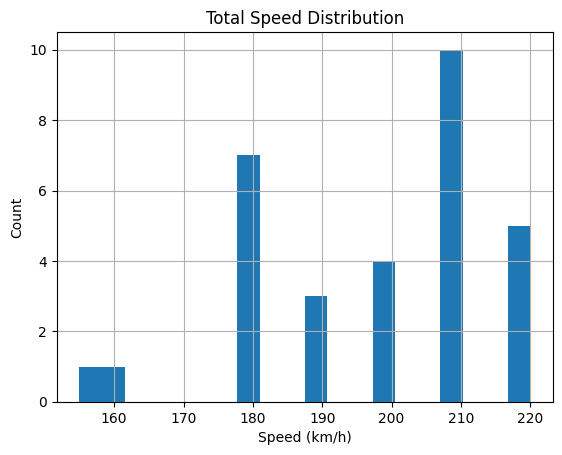

In [ ]:
print(df["Total Speed"].min())
print(df["Total Speed"].max())

df["Total Speed"].hist(bins=20)
plt.title("Total Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.ylabel("Count")
plt.show()

In [ ]:
levels = np.linspace(df["Total Speed"].min(), df["Total Speed"].max(), 6)
levels

array([155., 168., 181., 194., 207., 220.])

In [ ]:
CRITERIA["Total Speed"] = [f"≥{lvl}" for lvl in levels[:-1]]
print(CRITERIA)

{'Seats': ['8', '9', '12'], 'Total Speed': ['≥155.0', '≥168.0', '≥181.0', '≥194.0', '≥207.0']}


In [ ]:
def snap_to_bin_label(value, levels):
    extended = np.append(levels, np.inf)
    idx = np.digitize(value, extended) - 1
    idx = np.clip(idx, 0, len(levels) - 1)
    # use levels[idx] but cap at second-to-last level
    label_idx = min(idx, len(levels) - 2)
    return f"≥{levels[label_idx]}"

df["Total Speed"] = df["Total Speed"].apply(lambda x: snap_to_bin_label(x, levels))
print(df["Total Speed"].unique())

<StringArray>
['≥207.0', '≥155.0', '≥168.0', '≥181.0', '≥194.0']
Length: 5, dtype: str


## HorsePower:

In [ ]:
print(df["HorsePower"])

197           285 hp
286           261 hp
327     102 - 204 hp
387           400 HP
414           400 HP
451           129 HP
677           392 hp
678           471 hp
712           355 hp
741           420 hp
751           355 hp
753           355 hp
754           355 hp
759           355 hp
763           355 hp
764           420 hp
771           420 hp
780           420 hp
783           355 hp
784           355 hp
798           420 hp
801           355 hp
808           355 hp
814           420 hp
818           355 hp
834           290 hp
847           290 hp
856           290 hp
867           290 hp
875           290 hp
1023    375 - 400 hp
Name: HorsePower, dtype: str


In [ ]:
df["HorsePower"] = (df["HorsePower"]
    .str.replace(" hp", "", case=False)
    .str.replace(",", "")
    .str.strip()
    .str.split(" - ")
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2 if len(x) == 2 else int(x[0]))
)
print(df["HorsePower"])

197     285.0
286     261.0
327     153.0
387     400.0
414     400.0
451     129.0
677     392.0
678     471.0
712     355.0
741     420.0
751     355.0
753     355.0
754     355.0
759     355.0
763     355.0
764     420.0
771     420.0
780     420.0
783     355.0
784     355.0
798     420.0
801     355.0
808     355.0
814     420.0
818     355.0
834     290.0
847     290.0
856     290.0
867     290.0
875     290.0
1023    387.5
Name: HorsePower, dtype: float64


129.0
471.0


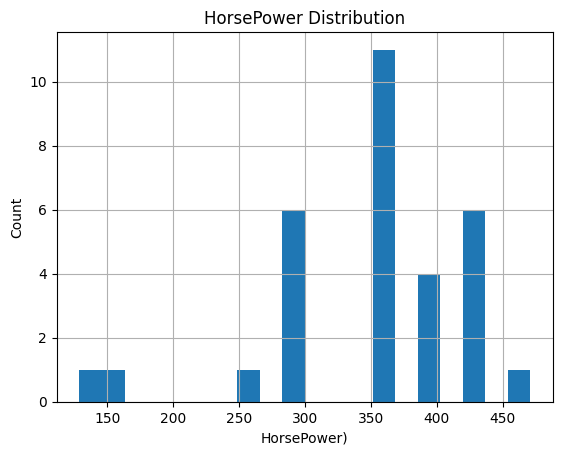

In [ ]:
print(df["HorsePower"].min())
print(df["HorsePower"].max())

df["HorsePower"].hist(bins=20)
plt.title("HorsePower Distribution")
plt.xlabel("HorsePower)")
plt.ylabel("Count")
plt.show()

In [ ]:
levels = np.linspace(df["HorsePower"].min(), df["HorsePower"].max(), 6)
levels

CRITERIA["HorsePower"] = [f"≥{lvl}" for lvl in levels[:-1]]
print(CRITERIA)

df["HorsePower"] = df["HorsePower"].apply(lambda x: snap_to_bin_label(x, levels))
print(df["HorsePower"].unique())

{'Seats': ['8', '9', '12'], 'Total Speed': ['≥155.0', '≥168.0', '≥181.0', '≥194.0', '≥207.0'], 'HorsePower': ['≥129.0', '≥197.4', '≥265.8', '≥334.20000000000005', '≥402.6']}
<StringArray>
['≥265.8', '≥197.4', '≥129.0', '≥334.20000000000005', '≥402.6']
Length: 5, dtype: str


## Price:

In [ ]:
print(df["Cars Prices"])

197              $40,000 
286              $33,000 
327              $35,000 
387              $51,000 
414              $65,300 
451              $28,000 
677              $63,595 
678              $91,495 
712              $59,900 
741              $82,400 
751              $64,400 
753              $56,995 
754              $62,495 
759              $65,500 
763              $57,400 
764              $61,100 
771              $72,800 
780              $93,800 
783              $71,505 
784              $73,305 
798              $76,805 
801              $65,000 
808              $75,000 
814              $90,000 
818              $78,000 
834              $42,500 
847              $39,500 
856              $47,000 
867              $43,500 
875              $45,500 
1023    $50,000 - $75,000
Name: Cars Prices, dtype: str


In [ ]:
df["Cars Prices"] = (df["Cars Prices"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "")
    .str.strip()
    .str.split(" - ")
    .apply(lambda x: (int(x[0]) + int(x[1])) / 2 if len(x) == 2 else int(x[0]))
)
print(df["Cars Prices"])

197     40000.0
286     33000.0
327     35000.0
387     51000.0
414     65300.0
451     28000.0
677     63595.0
678     91495.0
712     59900.0
741     82400.0
751     64400.0
753     56995.0
754     62495.0
759     65500.0
763     57400.0
764     61100.0
771     72800.0
780     93800.0
783     71505.0
784     73305.0
798     76805.0
801     65000.0
808     75000.0
814     90000.0
818     78000.0
834     42500.0
847     39500.0
856     47000.0
867     43500.0
875     45500.0
1023    62500.0
Name: Cars Prices, dtype: float64


28000.0
93800.0


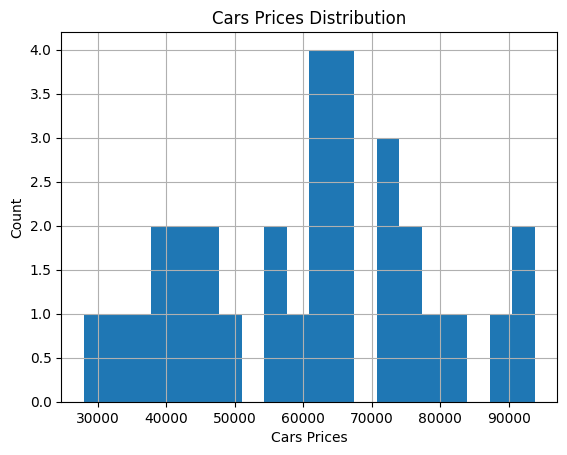

In [ ]:
print(df["Cars Prices"].min())
print(df["Cars Prices"].max())

df["Cars Prices"].hist(bins=20)
plt.title("Cars Prices Distribution")
plt.xlabel("Cars Prices")
plt.ylabel("Count")
plt.show()

In [ ]:
levels = np.linspace(df["Cars Prices"].max(), df["Cars Prices"].min(), 6)

levels_sorted = np.sort(levels)  # ascending for digitize
levels_desc = levels             # descending for labels (best → worst)

CRITERIA["Cars Prices"] = [f"≤{lvl}" for lvl in levels_desc[:-1]]

def snap_to_bin_label_cost(value, levels_asc, levels_desc):
    extended = np.append(levels_asc, np.inf)
    idx = np.digitize(value, extended) - 1
    idx = np.clip(idx, 0, len(levels_asc) - 2)
    # invert index so cheap = high bin
    inv_idx = len(levels_desc) - 2 - idx
    return f"≤{levels_desc[inv_idx]}"

df["Cars Prices"] = df["Cars Prices"].apply(
    lambda x: snap_to_bin_label_cost(x, levels_sorted, levels_desc)
)
print(df["Cars Prices"].unique())

<StringArray>
['≤41160.0', '≤54320.0', '≤67480.0', '≤93800.0', '≤80640.0']
Length: 5, dtype: str


## Preferences:

In [ ]:
print(df["Company Names"].unique())

<StringArray>
['HONDA', 'Nissan', 'Volkswagen', 'Jeep', 'Chevrolet', 'GMC', 'Kia', 'Ford']
Length: 8, dtype: str


In [ ]:
honda_cars = df[df["Company Names"] == "HONDA"]["Cars Names"].tolist()
nissan_cars = df[df["Company Names"] == "Nissan"]["Cars Names"].tolist()
kia_cars = df[df["Company Names"] == "Kia"]["Cars Names"].tolist()
gmc_cars = df[df["Company Names"] == "GMC"]["Cars Names"].tolist()
chevy_cars = df[df["Company Names"] == "Chevrolet"]["Cars Names"].tolist()
jeep_cars = df[df["Company Names"] == "Jeep"]["Cars Names"].tolist()

PREFERENCES = [
    # Cycle (Inconsistency)
    ("PILOT", "NV1500"),
    ("NV1500", "Carnival EX"),
    ("Carnival EX", "PILOT"),
    
    # Additional preferences
    ("Yukon", "NV1500"),
    ("Suburban", "Wagoneer")
]

# Dataset description:

1. domain of problem is about choosing the best car for Michał.

2. source of data is kaggle dataset: https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025

3. Michał wants the car that is cheap (as he has not found internship yet), that is fast, but also important factor is that the car shall have many seats - Michał wants to do a walcome party in his car, and be able to invite as many people as possible.

4. Michał considered 31 alternatives - only cars with number of seats equal to 8 or more. But the Michał shrank his dataset to 8 random options from this so that he could use not only uta but also ahp on whole dataset and compare results. This is much less alternatives than in original dataset.

5. One alternative from original dataset is FERRARI SF90 STRADALE:

- Engines: V8   
- CC/Battery Capacity: 3990 cc 
- HorsePower: 963 hp
- Total Speed: 340 km/h 
- Performance(0 - 100 )KM/H: 2.5 sec 
- Cars Prices: $1,100,000 
- Fuel Types: plug in hyrbrid
- Seats: 2
- Torque: 800 Nm

  But Michał does not include this alternative, it has only 2 seats - it might be an acceptable choice for a date, but not for a legendary party that Michał wants to organize.

6. Michał considers four criteria: 
- seats
- car price
- total speed
- HorsePower
  Michał also has some self-contradictory preferences regarding his favourite car models.

  In the original data set there were more criteria: engines, CC/battery capacity, performance (0 - 100)km/h, fual types, torque, but Michał does not consider those criteria. Four criteria that Michał chose are fully sufficient.

7. 
- seats is discrete gain type criterium
- total speed is gain type, it was continuous, we divided it into 5 categories: ['≥155.0', '≥168.0', '≥181.0', '≥194.0', '≥207.0']
  car price and HorsePower also were continuous, we divided them into categories similar way. 

  For price, which was cost type, we inverted ordering, so that the cheapest correspond to best.
  
  While transforming continuous categories into discrete ones, we did not take outliers, as we saw that in each case there were not that many (Ferrari would be outlier compared to cars Michał chose from, but we did not consider it). In each case we did divide distirbution linearly into categories.

8. All 4 criteria that were considered are of equal importance. Other criteria are irrelevant.

10. In my opinion the best alternative would be Ferrari, but Michał wants to consider alternative that has 8 seats or more, if that constraint is fulfilled, then he wants to consider number of seats, horse power, total speed, and price as similarly important.

11. There is no alternative that seems to be much better than the others. One alternative that can be considered is Honda Pilot - it costs 40,000$, so is realtively cheap, total speed of 209 km/h, what is better score than average among considered alternatives, and its horse power is not worse than many other alternatives. So it is good not because of one outsanding criterium, but because of good overall value of criteria.

12. One of alternatives that seems not that strong is Kia Carnival EX. It is quite cheap, and decently fast, but has quite small horse power. It is not a very bad car, and there is no one major disadvantage.

13. 

- Kia Carnival EX vs Nissan NV1500: Kia has better horse power, and is much faster, but Nissan can fit staggering 12 people compared to just 8, it is also cheaper.

- Ferrari vs Nissan NV1500: Ferrari can fit only 2 people compared to 12.

# Checking feasibility (UTA 2.1):

In [ ]:
MIN_WEIGHT = 0.1 # floor per criterion
MAX_WEIGHT = 0.5 # ceiling per criterion
N_CRITERIA = len(CRITERIA)

print(CRITERIA)

{'Seats': ['8', '9', '12'], 'Total Speed': ['≥155.0', '≥168.0', '≥181.0', '≥194.0', '≥207.0'], 'HorsePower': ['≥129.0', '≥197.4', '≥265.8', '≥334.20000000000005', '≥402.6'], 'Cars Prices': ['≤93800.0', '≤80640.0', '≤67480.0', '≤54320.0', '≤41160.0']}


In [ ]:
EPSILON = 0.01 # strict preference margin

print(PREFERENCES)

[('PILOT', 'NV1500'), ('NV1500', 'Carnival EX'), ('Carnival EX', 'PILOT'), ('Yukon', 'NV1500'), ('Suburban', 'Wagoneer')]


In [ ]:
selected_criteria = list(CRITERIA.keys())

AHP_ALT_NAMES = [
    "PILOT", "NV1500", "Transporter", "Carnival EX", 
    "Expedition", "Yukon", "Suburban", "Wagoneer"
]

# Filter the dataframe so UTA and AHP use the same dataset
df = df[df["Cars Names"].isin(AHP_ALT_NAMES)]

ALTERNATIVES = {
    row["Cars Names"]: {col: row[col] for col in selected_criteria}
    for _, row in df.iterrows()
}

print(ALTERNATIVES)

{'PILOT': {'Seats': '8', 'Total Speed': '≥207.0', 'HorsePower': '≥265.8', 'Cars Prices': '≤41160.0'}, 'NV1500': {'Seats': '12', 'Total Speed': '≥155.0', 'HorsePower': '≥197.4', 'Cars Prices': '≤41160.0'}, 'Transporter': {'Seats': '9', 'Total Speed': '≥168.0', 'HorsePower': '≥129.0', 'Cars Prices': '≤41160.0'}, 'Wagoneer': {'Seats': '8', 'Total Speed': '≥181.0', 'HorsePower': '≥334.20000000000005', 'Cars Prices': '≤67480.0'}, 'Suburban': {'Seats': '8', 'Total Speed': '≥181.0', 'HorsePower': '≥334.20000000000005', 'Cars Prices': '≤67480.0'}, 'Yukon': {'Seats': '8', 'Total Speed': '≥168.0', 'HorsePower': '≥334.20000000000005', 'Cars Prices': '≤67480.0'}, 'Carnival EX': {'Seats': '8', 'Total Speed': '≥207.0', 'HorsePower': '≥265.8', 'Cars Prices': '≤54320.0'}, 'Expedition': {'Seats': '8', 'Total Speed': '≥168.0', 'HorsePower': '≥334.20000000000005', 'Cars Prices': '≤67480.0'}}


Here we define function that will check if all problem constraints (weight bounds, non-flatness, monotonicity) along with preferential constraints can give us any feasible solution at all. 

In [ ]:
def build_and_solve_inconsistency(active_pref_indices, verbose=False):
    # only preferences with active_pref_indices are active

    prob = LpProblem("UTA_Inconsistency", LpMinimize)
 
    # Marginal value variables  u_c(x)
    # u[crit][level_index]
    u = {}
    for crit, levels in CRITERIA.items():
        u[crit] = {
            lvl: LpVariable(f"u_{crit}_{i}", lowBound=0, upBound=1)
            for i, lvl in enumerate(levels)
        }
 
    # monotonicity
    for crit, levels in CRITERIA.items():
        for i in range(len(levels) - 1):
            prob += (u[crit][levels[i]] <= u[crit][levels[i+1]],
                     f"Mono_{crit}_{i}")
 
    # Normalization: lowest level = 0 for each criterion
    for crit, levels in CRITERIA.items():
        prob += (u[crit][levels[0]] == 0, f"Norm_low_{crit}")
 
    # Normalization: sum of tops = 1
    prob += (
        lpSum(u[crit][levels[-1]] for crit, levels in CRITERIA.items()) == 1,
        "Norm_total"
    )
 
    # Weight bounds  (top level value = weight of criterion)
    for crit, levels in CRITERIA.items():
        w = u[crit][levels[-1]]
        prob += (w <= MAX_WEIGHT, f"MaxW_{crit}")
        prob += (w >= MIN_WEIGHT, f"MinW_{crit}")
 
    # Non-flatness constraints:
    # Ensure each criterion has at least two "steps" of ≥ 0.05
    # i.e. the spread from level[0] to level[-1] ≥ 0.15
    # AND at least one internal "jump" ≥ 0.04
    for crit, levels in CRITERIA.items():
        top = u[crit][levels[-1]]
        prob += (top >= 0.15, f"NonFlat_spread_{crit}")
        # At least one consecutive pair must differ by ≥ 0.04
        # Encoded via auxiliary binary + big-M – simpler: require
        # that the midpoint level is NOT equal to both ends,
        # i.e. u[mid] ≥ u[low] + 0.04  OR  u[high] ≥ u[mid] + 0.04
        # We enforce BOTH internal gaps together ≥ 0.04 (relaxed form)
        if len(levels) >= 3:
            mid = levels[len(levels) // 2]
            prob += (u[crit][mid] - u[crit][levels[0]] >= 0.04, f"NonFlat_lo_{crit}")
            prob += (u[crit][levels[-1]] - u[crit][mid] >= 0.04, f"NonFlat_hi_{crit}")
 
    # Utility of each alternative
    U = {}
    for alt, evals in ALTERNATIVES.items():
        U[alt] = lpSum(u[crit][evals[crit]] for crit in CRITERIA)
 
    # Preference constraints (only active ones)
    for idx in active_pref_indices:
        a, b = PREFERENCES[idx]
        prob += (U[a] >= U[b] + EPSILON, f"Pref_{idx}_{a}_gt_{b}")
 
    # Objective: minimise sum of weights (feasibility probe – any min works)
    prob += lpSum(u[crit][levels[-1]] for crit, levels in CRITERIA.items())
 
    solver = pulp.PULP_CBC_CMD(msg=0)
    prob.solve(solver)
 
    status = LpStatus[prob.status]
    if verbose:
        print(f"  Status: {status}")
 
    if status == "Optimal":
        result = {}
        for crit, levels in CRITERIA.items():
            result[crit] = {lvl: value(u[crit][lvl]) for lvl in levels}
        result["_utilities"] = {alt: value(U[alt]) for alt in ALTERNATIVES}
        return status, result
    return status, None
 
def find_all_mis(all_indices):
    """
    Enumerate all Minimal Inconsistent Subsets by brute-force
    (feasible for small preference sets).
    A subset S is MIS iff S is infeasible but every proper subset is feasible.
    """
    n = len(all_indices)
    mis_list = []
 
    for size in range(1, n + 1):
        for subset in combinations(all_indices, size):
            subset = list(subset)
            # Skip if a known MIS is already a sub-set of this subset
            if any(set(m).issubset(set(subset)) for m in mis_list):
                continue
            status, _ = build_and_solve_inconsistency(subset)
            if status != "Optimal":
                # Check minimality: every proper subset must be feasible
                is_minimal = True
                for drop in subset:
                    reduced = [x for x in subset if x != drop]
                    s2, _ = build_and_solve_inconsistency(reduced)
                    if s2 != "Optimal":
                        is_minimal = False
                        break
                if is_minimal:
                    mis_list.append(subset)
    return mis_list
 
 
def find_maximal_consistent_subsets(all_indices, mis_list):
    """
    A subset S is a Maximal Consistent Subset (MCS) iff it is feasible
    and no proper superset is feasible.
    Equivalently, each MCS is the complement of a minimal hitting set of the MIS family.
    We enumerate directly for clarity.
    """
    n = len(all_indices)
    mcs_list = []
 
    # check all subsets from largest down
    for size in range(n, 0, -1):
        for subset in combinations(all_indices, size):
            subset = list(subset)
            # Already covered by a larger MCS?
            if any(set(subset).issubset(set(m)) for m in mcs_list):
                continue
            # Must not contain any MIS
            if any(set(m).issubset(set(subset)) for m in mis_list):
                continue
            status, _ = build_and_solve_inconsistency(subset)
            if status == "Optimal":
                mcs_list.append(subset)
    return mcs_list

In [ ]:
active_pref_idxs = list(range(len(PREFERENCES)))

print("System feasibility check:")
status, _ = build_and_solve_inconsistency(active_pref_idxs, verbose=True)

if status == "Optimal":
    print("All preferences are consistent. No inconsistency to resolve.")
else:
    print("System is INFEASIBLE - inconsistency detected.")

    print("\nFinding Minimal Inconsistent Subsets (MIS):")
    mis_list = find_all_mis(active_pref_idxs)
    for mis in mis_list:
        labels = [f"P{i+1}({PREFERENCES[i][0]}≻{PREFERENCES[i][1]})" for i in mis]
        print(f"  MIS: {{ {', '.join(labels)} }}")


    print("\nFinding Maximal Consistent Subsets (MCS):")
    mcs_list = find_maximal_consistent_subsets(active_pref_idxs, mis_list)
    mcs_list.sort(key=lambda s: -len(s))

    for k, mcs in enumerate(mcs_list):
        removed = sorted(set(active_pref_idxs) - set(mcs))
        removed_labels = [f"P{i+1}" for i in removed]
        mcs_labels = [f"P{i+1}" for i in sorted(mcs)]
        print(f"  MCS #{k+1} — keeps {mcs_labels}, removes {removed_labels}")

    print("\nCommon core (in ALL MCS)")
    core = set(mcs_list[0])
    for mcs in mcs_list[1:]:
        core &= set(mcs)
    core_labels = [f"P{i+1}({PREFERENCES[i][0]}≻{PREFERENCES[i][1]})" for i in sorted(core)]
    print(f"  Core preferences: {core_labels}")

System feasibility check:
  Status: Infeasible
System is INFEASIBLE - inconsistency detected.

Finding Minimal Inconsistent Subsets (MIS):
  MIS: { P3(Carnival EX≻PILOT) }
  MIS: { P5(Suburban≻Wagoneer) }

Finding Maximal Consistent Subsets (MCS):
  MCS #1 — keeps ['P1', 'P2', 'P4'], removes ['P3', 'P5']

Common core (in ALL MCS)
  Core preferences: ['P1(PILOT≻NV1500)', 'P2(NV1500≻Carnival EX)', 'P4(Yukon≻NV1500)']


The system is infeasible because preferences P1–P3 form a cycle
(honda ≻ nissan ≻ kia ≻ honda).  The MIS/MCS analysis above identifies
which preferences to keep.  We take the **largest MCS** (removing the
fewest preferences) and proceed with UTA 2.2 — maximising the distance
between the utility of reference alternatives that are in a preference
relationship (the most discriminant value function).

# Solving problem with objective function (UTA 2.2):

The only difference from function **build_and_solve_inconsistency** is:

- LpMinimize -> LpMaximize
- Objective: lpSum(U[a] - U[b] for all active pairs) instead of lpSum(weights)
- returns _objective value in the result dict


In [ ]:
def build_and_solve_objective(active_pref_indices, verbose=False):
    """
    UTA 2.2 — Maximise discrimination between preferred alternatives.
    Objective: maximise sum of (U[a] - U[b]) for all active preference pairs.
    Returns (status_str, variable_dict or None).
    """
    prob = LpProblem("UTA_22_Discriminant", LpMaximize)

    # Marginal value variables u_c(x)
    u = {}
    for crit, levels in CRITERIA.items():
        u[crit] = {
            lvl: LpVariable(f"u_{crit}_{i}", lowBound=0, upBound=1)
            for i, lvl in enumerate(levels)
        }

    # Monotonicity
    for crit, levels in CRITERIA.items():
        for i in range(len(levels) - 1):
            prob += (u[crit][levels[i]] <= u[crit][levels[i+1]], f"Mono_{crit}_{i}")

    # Normalization: lowest level = 0 for each criterion
    for crit, levels in CRITERIA.items():
        prob += (u[crit][levels[0]] == 0, f"Norm_low_{crit}")

    # Normalization: sum of tops = 1
    prob += (
        lpSum(u[crit][levels[-1]] for crit, levels in CRITERIA.items()) == 1,
        "Norm_total"
    )

    # Weight bounds
    for crit, levels in CRITERIA.items():
        w = u[crit][levels[-1]]
        prob += (w <= MAX_WEIGHT, f"MaxW_{crit}")
        prob += (w >= MIN_WEIGHT, f"MinW_{crit}")

    # Non-flatness constraints
    for crit, levels in CRITERIA.items():
        top = u[crit][levels[-1]]
        prob += (top >= 0.15, f"NonFlat_spread_{crit}")
        if len(levels) >= 3:
            mid = levels[len(levels) // 2]
            prob += (u[crit][mid] - u[crit][levels[0]] >= 0.04, f"NonFlat_lo_{crit}")
            prob += (u[crit][levels[-1]] - u[crit][mid] >= 0.04, f"NonFlat_hi_{crit}")

    # Utility of each alternative
    U = {}
    for alt, evals in ALTERNATIVES.items():
        U[alt] = lpSum(u[crit][evals[crit]] for crit in CRITERIA)

    # Preference constraints
    for idx in active_pref_indices:
        a, b = PREFERENCES[idx]
        prob += (U[a] >= U[b] + EPSILON, f"Pref_{idx}_{a}_gt_{b}")

    # Objective: maximise sum of utility gaps
    prob += lpSum(
        U[PREFERENCES[idx][0]] - U[PREFERENCES[idx][1]]
        for idx in active_pref_indices
    )

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    status = LpStatus[prob.status]
    if verbose:
        print(f"  Status: {status}")
        print(f"  Objective (total utility gap): {value(prob.objective):.4f}")

    if status == "Optimal":
        result = {}
        for crit, levels in CRITERIA.items():
            result[crit] = {lvl: value(u[crit][lvl]) for lvl in levels}
        result["_utilities"] = {alt: value(U[alt]) for alt in ALTERNATIVES}
        result["_objective"] = value(prob.objective)
        return status, result
    
    return status, None

In [ ]:
largest_mcs = max(mcs_list, key=lambda s: len(s))

status, result = build_and_solve_objective(largest_mcs, verbose=True)

  Status: Optimal
  Objective (total utility gap): 0.5100


In [ ]:
print(result)

{'Seats': {'8': 0.0, '9': 0.04, '12': 0.15}, 'Total Speed': {'≥155.0': 0.0, '≥168.0': 0.16, '≥181.0': 0.16, '≥194.0': 0.16, '≥207.0': 0.2}, 'HorsePower': {'≥129.0': 0.0, '≥197.4': 0.0, '≥265.8': 0.04, '≥334.20000000000005': 0.5, '≥402.6': 0.5}, 'Cars Prices': {'≤93800.0': 0.0, '≤80640.0': 0.0, '≤67480.0': 0.04, '≤54320.0': 0.04, '≤41160.0': 0.15}, '_utilities': {'PILOT': 0.39, 'NV1500': 0.3, 'Transporter': 0.35, 'Wagoneer': 0.7000000000000001, 'Suburban': 0.7000000000000001, 'Yukon': 0.7000000000000001, 'Carnival EX': 0.28, 'Expedition': 0.7000000000000001}, '_objective': 0.51}


In [ ]:
top5 = sorted(result["_utilities"], key=lambda x: result["_utilities"][x], reverse=True)[:5]
for rank, car in enumerate(top5, 1):
    company = df[df["Cars Names"] == car]["Company Names"].values[0]
    print(f"{rank}. {car} by {company} (utility: {result['_utilities'][car]:.4f})")

1. Wagoneer by Jeep (utility: 0.7000)
2. Suburban by Chevrolet (utility: 0.7000)
3. Yukon by GMC (utility: 0.7000)
4. Expedition by Ford (utility: 0.7000)
5. PILOT by HONDA (utility: 0.3900)


In [ ]:
# variables and their values
for crit, levels in CRITERIA.items():
    for lvl in levels:
        print(f"u_{crit}_{lvl} = {result[crit][lvl]:.4f}")

print("\nPreference constaints:")
for idx in largest_mcs:
    a, b = PREFERENCES[idx]
    ua = result["_utilities"][a]
    ub = result["_utilities"][b]
    print(f"U({a}) >= U({b}) + {EPSILON}  →  {ua:.4f} >= {ub:.4f} + {EPSILON}")

print("\nCriterion weights:")
for crit, levels in CRITERIA.items():
    weight = result[crit][levels[-1]]
    print(f"  {crit}: {weight:.4f}")

u_Seats_8 = 0.0000
u_Seats_9 = 0.0400
u_Seats_12 = 0.1500
u_Total Speed_≥155.0 = 0.0000
u_Total Speed_≥168.0 = 0.1600
u_Total Speed_≥181.0 = 0.1600
u_Total Speed_≥194.0 = 0.1600
u_Total Speed_≥207.0 = 0.2000
u_HorsePower_≥129.0 = 0.0000
u_HorsePower_≥197.4 = 0.0000
u_HorsePower_≥265.8 = 0.0400
u_HorsePower_≥334.20000000000005 = 0.5000
u_HorsePower_≥402.6 = 0.5000
u_Cars Prices_≤93800.0 = 0.0000
u_Cars Prices_≤80640.0 = 0.0000
u_Cars Prices_≤67480.0 = 0.0400
u_Cars Prices_≤54320.0 = 0.0400
u_Cars Prices_≤41160.0 = 0.1500

Preference constaints:
U(PILOT) >= U(NV1500) + 0.01  →  0.3900 >= 0.3000 + 0.01
U(NV1500) >= U(Carnival EX) + 0.01  →  0.3000 >= 0.2800 + 0.01
U(Yukon) >= U(NV1500) + 0.01  →  0.7000 >= 0.3000 + 0.01

Criterion weights:
  Seats: 0.1500
  Total Speed: 0.2000
  HorsePower: 0.5000
  Cars Prices: 0.1500


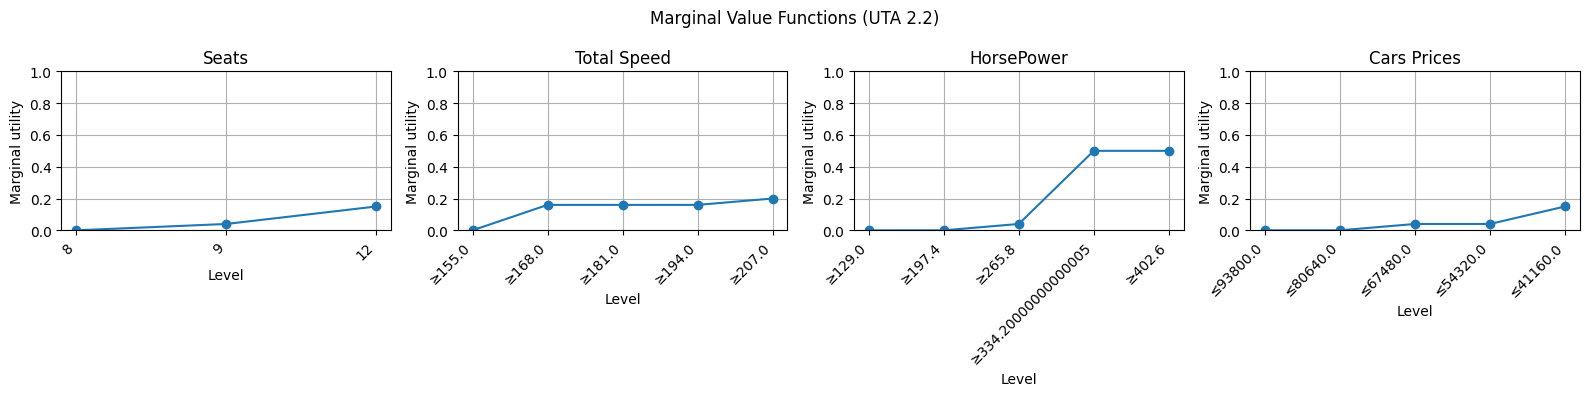

In [ ]:
max_utility = 1.0  # all scaled to same max
n_criteria = len(CRITERIA)
fig, axes = plt.subplots(1, n_criteria, figsize=(4 * n_criteria, 4))

for ax, (crit, levels) in zip(axes, CRITERIA.items()):
    values = [result[crit][lvl] for lvl in levels]
    ax.plot(range(len(levels)), values, marker="o")
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels(levels, rotation=45, ha="right")
    ax.set_ylim(0, max_utility)
    ax.set_title(crit)
    ax.set_xlabel("Level")
    ax.set_ylabel("Marginal utility")
    ax.grid(True)

plt.suptitle("Marginal Value Functions (UTA 2.2)")
plt.tight_layout()
plt.show()

# AHP (Analytic Hierarchy Process)

We build a 4-level hierarchy:
- **Goal**: Best Family / Commercial Vehicle
- **Categories**: Performance (Total Speed, HorsePower) and Economy (Seats, Cars Prices)
- **Criteria**: the 4 criteria under their respective categories
- **Alternatives**: 8 selected cars

All pairwise comparisons use the Saaty 1–9 scale and are provided by
the decision maker (not derived from data).

In [ ]:
from scipy.stats import kendalltau

## Selecting 8 alternatives for AHP

We pick 8 cars from different companies and seat counts to keep the
pairwise-comparison matrices manageable (28 upper-triangle entries each).

In [ ]:
AHP_ALT_NAMES = [
    "PILOT",               # HONDA,      seats=8,  speed=209, hp=285,  price=$40,000
    "NV1500",              # Nissan,     seats=12, speed=160, hp=261,  price=$33,000
    "Transporter",         # Volkswagen, seats=9,  speed=180, hp=153,  price=$35,000
    "Carnival EX",         # Kia,        seats=8,  speed=220, hp=290,  price=$47,000
    "Expedition",          # Ford,       seats=8,  speed=180, hp=388,  price=$62,500
    "Yukon",        # GMC,        seats=8,  speed=200, hp=420,  price=$72,800
    "Suburban",            # Chevrolet,  seats=8,  speed=190, hp=355,  price=$59,900
    "Wagoneer",            # Jeep,       seats=8,  speed=190, hp=392,  price=$63,595
]

ahp_alts = [name for name in AHP_ALT_NAMES if name in ALTERNATIVES]
print(f"AHP alternatives ({len(ahp_alts)}):")
for a in ahp_alts:
    company = df[df["Cars Names"] == a]["Company Names"].values[0]
    print(f"  {a:30s} ({company})")

assert len(ahp_alts) == 8, f"Expected 8 alternatives, got {len(ahp_alts)}"
N_AHP = len(ahp_alts)

AHP alternatives (8):
  PILOT                          (HONDA)
  NV1500                         (Nissan)
  Transporter                    (Volkswagen)
  Carnival EX                    (Kia)
  Expedition                     (Ford)
  Yukon                          (GMC)
  Suburban                       (Chevrolet)
  Wagoneer                       (Jeep)


## Core AHP functions

In [ ]:
# Saaty Random Index table (for n = 1..15)
RI_TABLE = {
    1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
    6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49,
    11: 1.51, 12: 1.48, 13: 1.56, 14: 1.57, 15: 1.59,
}


def eigenvector_weights(matrix):
    """Compute AHP priority vector via the principal eigenvector."""
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    # principal eigenvalue = the one with largest real part
    idx = np.argmax(np.real(eigenvalues))
    lambda_max = np.real(eigenvalues[idx])
    w = np.real(eigenvectors[:, idx])
    w = np.abs(w)
    w = w / w.sum()  # normalise to sum = 1
    return w, lambda_max


def consistency_ratio(matrix, weights=None, lambda_max=None):
    """Compute CI and CR. Recomputes weights if not provided."""
    n = matrix.shape[0]
    if weights is None or lambda_max is None:
        weights, lambda_max = eigenvector_weights(matrix)
    CI = (lambda_max - n) / (n - 1) if n > 1 else 0.0
    RI = RI_TABLE.get(n, 1.59)
    CR = CI / RI if RI > 0 else 0.0
    return CI, CR


def reconstruct_matrix(weights):
    """Build the ideal consistent matrix from a weight vector: A[i,j] = w[i]/w[j]."""
    n = len(weights)
    return np.array([[weights[i] / weights[j] for j in range(n)] for i in range(n)])


def make_reciprocal(n, upper_triangle):
    """
    Build an n×n reciprocal matrix from a flat list of upper-triangle values.
    upper_triangle has n*(n-1)/2 elements in row-major order:
      (0,1), (0,2), …, (0,n-1), (1,2), …, (n-2,n-1)
    """
    M = np.ones((n, n))
    k = 0
    for i in range(n):
        for j in range(i + 1, n):
            M[i, j] = upper_triangle[k]
            M[j, i] = 1.0 / upper_triangle[k]
            k += 1
    return M


def print_ahp_result(name, matrix, labels):
    """Solve and print weights + CR for one comparison matrix."""
    w, lmax = eigenvector_weights(matrix)
    ci, cr = consistency_ratio(matrix, w, lmax)
    tag = "CONSISTENT" if cr < 0.1 else "INCONSISTENT"
    print(f"\n--- {name} ---")
    print(f"  λ_max = {lmax:.4f},  CI = {ci:.4f},  CR = {cr:.4f}  [{tag}]")
    for lbl, wi in zip(labels, w):
        print(f"  {lbl:30s}  w = {wi:.4f}")
    return w, lmax, ci, cr

## Criteria-level pairwise comparisons

Three 2×2 matrices (always perfectly consistent since n=2):
1. **Goal level** — Performance vs Economy
2. **Performance sub-criteria** — Total Speed vs HorsePower
3. **Economy sub-criteria** — Seats vs Cars Prices

In [ ]:
# Goal level: Performance vs Economy
# DM judges Performance slightly more important (3 on Saaty scale)
M_goal = np.array([
    [1,   3],
    [1/3, 1],
])
categories = ["Performance", "Economy"]
w_goal, *_ = print_ahp_result("Goal: Performance vs Economy", M_goal, categories)


--- Goal: Performance vs Economy ---
  λ_max = 2.0000,  CI = 0.0000,  CR = 0.0000  [CONSISTENT]
  Performance                     w = 0.7500
  Economy                         w = 0.2500


In [ ]:
# Performance: Total Speed vs HorsePower
# DM judges HorsePower slightly more important (2 on Saaty scale)
M_perf = np.array([
    [1,   1/2],
    [2,   1],
])
perf_criteria = ["Total Speed", "HorsePower"]
w_perf, *_ = print_ahp_result("Performance: Speed vs HP", M_perf, perf_criteria)


--- Performance: Speed vs HP ---
  λ_max = 2.0000,  CI = 0.0000,  CR = 0.0000  [CONSISTENT]
  Total Speed                     w = 0.3333
  HorsePower                      w = 0.6667


In [ ]:
# Economy: Seats vs Cars Prices
# DM judges Price more important than Seats (3 on Saaty scale)
M_econ = np.array([
    [1,   1/3],
    [3,   1],
])
econ_criteria = ["Seats", "Cars Prices"]
w_econ, *_ = print_ahp_result("Economy: Seats vs Price", M_econ, econ_criteria)


--- Economy: Seats vs Price ---
  λ_max = 2.0000,  CI = 0.0000,  CR = 0.0000  [CONSISTENT]
  Seats                           w = 0.2500
  Cars Prices                     w = 0.7500


In [ ]:
# Global criterion weights
global_weights = {
    "Total Speed":  w_goal[0] * w_perf[0],
    "HorsePower":   w_goal[0] * w_perf[1],
    "Seats":        w_goal[1] * w_econ[0],
    "Cars Prices":  w_goal[1] * w_econ[1],
}
print("\nGlobal criterion weights:")
for crit, gw in global_weights.items():
    print(f"  {crit:15s}  {gw:.4f}")
print(f"  {'SUM':15s}  {sum(global_weights.values()):.4f}")


Global criterion weights:
  Total Speed      0.2500
  HorsePower       0.5000
  Seats            0.0625
  Cars Prices      0.1875
  SUM              1.0000


## Alternative pairwise comparisons (8×8 per criterion)

Order of alternatives:
0=PILOT, 1=NV1500, 2=Transporter, 3=Carnival SX Prestige,
4=Expedition, 5=Yukon Denali, 6=Suburban, 7=Wagoneer

Each upper_triangle list has 28 entries (row-major upper triangle).
**HorsePower matrix is intentionally inconsistent** (CR > 0.1).

In [ ]:
# --- Total Speed ---
# Ranking: Carnival(220)>Pilot(209)>Yukon(200)>Sub(190)=Wag(190)>Trans(180)=Exp(180)>NV(160)
speed_upper = [
    5,   3,   1/2, 3,   2,   2,   2,     # row 0 (Pilot)
         1/3, 1/7, 1/3, 1/5, 1/4, 1/4,   # row 1 (NV1500)
              1/4, 1,   1/2, 1/2, 1/2,    # row 2 (Transporter)
                   4,   3,   3,   3,      # row 3 (Carnival)
                        1/2, 1/2, 1/2,    # row 4 (Expedition)
                             2,   2,      # row 5 (Yukon)
                                  1,      # row 6 (Suburban)
]
M_speed = make_reciprocal(N_AHP, speed_upper)
w_speed, *_ = print_ahp_result("Alternatives – Total Speed", M_speed, ahp_alts)


--- Alternatives – Total Speed ---
  λ_max = 8.1669,  CI = 0.0238,  CR = 0.0169  [CONSISTENT]
  PILOT                           w = 0.1926
  NV1500                          w = 0.0286
  Transporter                     w = 0.0648
  Carnival EX                     w = 0.3001
  Expedition                      w = 0.0648
  Yukon                           w = 0.1415
  Suburban                        w = 0.1039
  Wagoneer                        w = 0.1039


In [ ]:
# --- HorsePower (INTENTIONALLY INCONSISTENT) ---
# True ranking: Yukon(420)>Wag(392)>Exp(388)>Sub(355)>Carnival(290)>Pilot(285)>NV(261)>Trans(153)
# Introduced inconsistencies:
#   - Pilot(285) vs Trans(153): DM says Trans is better (1/3) — contradicts reality
#   - Carnival(290) vs Exp(388): DM says Carnival 4× better — contradicts reality
#   - Exp(388) vs Wag(392): DM says Exp 3× better — exaggerated
hp_upper = [
    2,   1/3, 1/2, 1/4, 1/5, 1/3, 1/4,   # row 0 (Pilot) ← (0,2)=1/3 INCONSISTENT
         3,   1/2, 1/4, 1/5, 1/3, 1/4,    # row 1 (NV1500)
              1/5, 1/6, 1/7, 1/5, 1/6,    # row 2 (Transporter)
                   4,   1/3, 1/2, 1/3,    # row 3 (Carnival) ← (3,4)=4 INCONSISTENT
                        1/2, 2,   3,      # row 4 (Expedition) ← (4,7)=3 INCONSISTENT
                             3,   2,      # row 5 (Yukon)
                                  1/3,    # row 6 (Suburban)
]
M_hp = make_reciprocal(N_AHP, hp_upper)
w_hp, lmax_hp, ci_hp, cr_hp = print_ahp_result("Alternatives – HorsePower (INCONSISTENT)", M_hp, ahp_alts)


--- Alternatives – HorsePower (INCONSISTENT) ---
  λ_max = 9.4413,  CI = 0.2059,  CR = 0.1460  [INCONSISTENT]
  PILOT                           w = 0.0420
  NV1500                          w = 0.0447
  Transporter                     w = 0.0344
  Carnival EX                     w = 0.1487
  Expedition                      w = 0.1767
  Yukon                           w = 0.2581
  Suburban                        w = 0.1142
  Wagoneer                        w = 0.1812


In [ ]:
# --- Seats ---
# Ranking: NV(12) >> Trans(9) > rest (all 8, equal)
seats_upper = [
    1/5, 1/2, 1,   1,   1,   1,   1,     # row 0 (Pilot, 8)
         3,   5,   5,   5,   5,   5,     # row 1 (NV1500, 12)
              2,   2,   2,   2,   2,     # row 2 (Transporter, 9)
                   1,   1,   1,   1,     # row 3 (Carnival, 8)
                        1,   1,   1,     # row 4 (Expedition, 8)
                             1,   1,     # row 5 (Yukon, 8)
                                  1,     # row 6 (Suburban, 8)
]
M_seats = make_reciprocal(N_AHP, seats_upper)
w_seats, *_ = print_ahp_result("Alternatives – Seats", M_seats, ahp_alts)


--- Alternatives – Seats ---
  λ_max = 8.0031,  CI = 0.0004,  CR = 0.0003  [CONSISTENT]
  PILOT                           w = 0.0765
  NV1500                          w = 0.3916
  Transporter                     w = 0.1496
  Carnival EX                     w = 0.0765
  Expedition                      w = 0.0765
  Yukon                           w = 0.0765
  Suburban                        w = 0.0765
  Wagoneer                        w = 0.0765


In [ ]:
# --- Cars Prices (lower = better) ---
# Ranking: NV($33k)>Trans($35k)>Pilot($40k)>Carnival($47k)>Sub($60k)>Exp($62.5k)≈Wag($63.6k)>Yukon($72.8k)
price_upper = [
    1/2, 1/2, 2,   3,   4,   3,   3,     # row 0 (Pilot, $40k)
         1,   3,   5,   6,   4,   5,     # row 1 (NV1500, $33k)
              2,   4,   5,   4,   4,     # row 2 (Transporter, $35k)
                   2,   3,   2,   2,     # row 3 (Carnival, $47k)
                        2,   1/2, 1,     # row 4 (Expedition, $62.5k)
                             1/2, 1/2,   # row 5 (Yukon, $72.8k)
                                  1,     # row 6 (Suburban, $59.9k)
]
M_price = make_reciprocal(N_AHP, price_upper)
w_price, *_ = print_ahp_result("Alternatives – Cars Prices", M_price, ahp_alts)


--- Alternatives – Cars Prices ---
  λ_max = 8.1171,  CI = 0.0167,  CR = 0.0119  [CONSISTENT]
  PILOT                           w = 0.1626
  NV1500                          w = 0.2726
  Transporter                     w = 0.2410
  Carnival EX                     w = 0.1071
  Expedition                      w = 0.0545
  Yukon                           w = 0.0365
  Suburban                        w = 0.0670
  Wagoneer                        w = 0.0586


In [ ]:
# Summary of CRs
print("\nConsistency summary:")
alt_data = {
    "Total Speed":  (M_speed, w_speed),
    "HorsePower":   (M_hp,    w_hp),
    "Seats":        (M_seats, w_seats),
    "Cars Prices":  (M_price, w_price),
}
for crit_name, (M, w) in alt_data.items():
    ci, cr = consistency_ratio(M, w)
    tag = "OK" if cr < 0.1 else "INCONSISTENT"
    print(f"  {crit_name:15s}  CR = {cr:.4f}  [{tag}]")


Consistency summary:
  Total Speed      CR = 0.0169  [OK]
  HorsePower       CR = 0.1460  [INCONSISTENT]
  Seats            CR = 0.0003  [OK]
  Cars Prices      CR = 0.0119  [OK]


## Inconsistency analysis

For every matrix with CR ≥ 0.1 we reconstruct the ideal consistent matrix
from the eigenvector weights and highlight the largest discrepancy.


=== HorsePower (CR = 0.1460) ===
  Largest discrepancy at (Carnival EX, Expedition):
    DM provided:   4.0000
    Reconstructed: 0.8418
    Difference:    3.1582


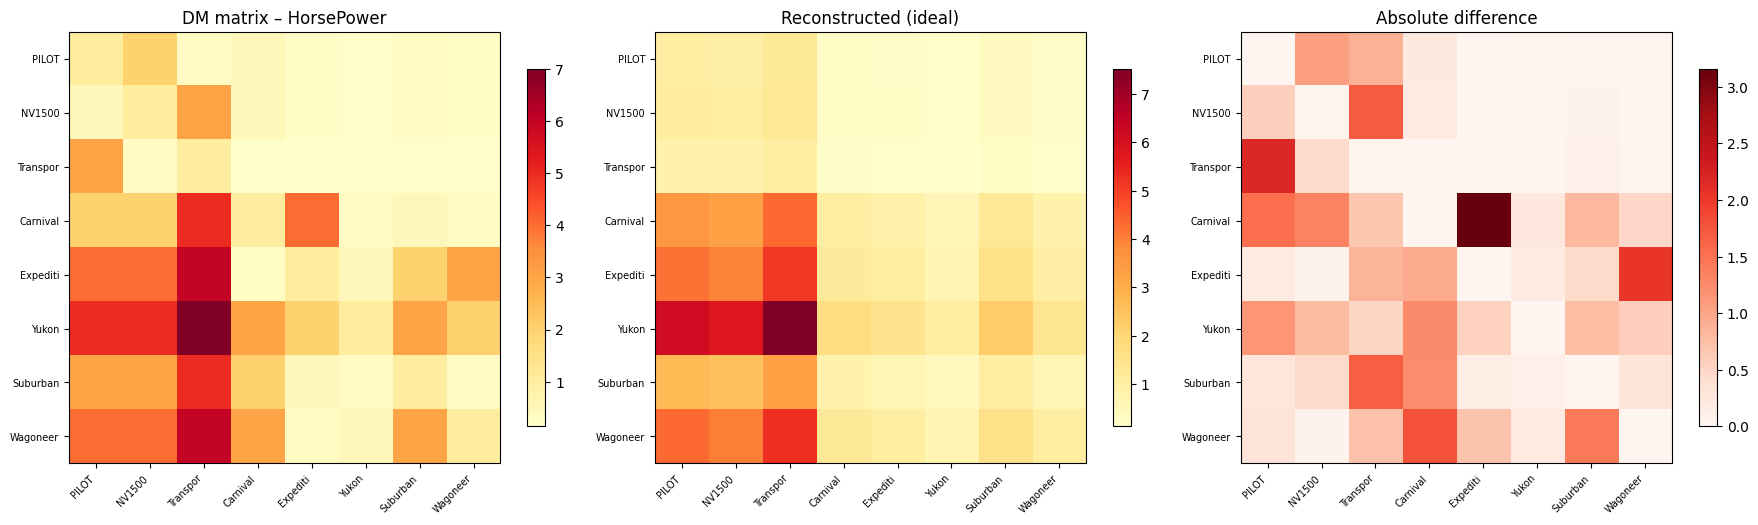

In [ ]:
for crit_name, (M, w) in alt_data.items():
    ci, cr = consistency_ratio(M, w)
    if cr < 0.1:
        continue

    print(f"\n=== {crit_name} (CR = {cr:.4f}) ===")

    M_ideal = reconstruct_matrix(w)
    diff = np.abs(M - M_ideal)

    i_max, j_max = np.unravel_index(np.argmax(diff), diff.shape)
    print(f"  Largest discrepancy at ({ahp_alts[i_max]}, {ahp_alts[j_max]}):")
    print(f"    DM provided:   {M[i_max, j_max]:.4f}")
    print(f"    Reconstructed: {M_ideal[i_max, j_max]:.4f}")
    print(f"    Difference:    {diff[i_max, j_max]:.4f}")

    # Heatmap of differences
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].imshow(M, cmap="YlOrRd")
    axes[0].set_title(f"DM matrix – {crit_name}")
    plt.colorbar(im0, ax=axes[0], shrink=0.8)

    im1 = axes[1].imshow(M_ideal, cmap="YlOrRd")
    axes[1].set_title("Reconstructed (ideal)")
    plt.colorbar(im1, ax=axes[1], shrink=0.8)

    im2 = axes[2].imshow(diff, cmap="Reds")
    axes[2].set_title("Absolute difference")
    plt.colorbar(im2, ax=axes[2], shrink=0.8)

    short_names = [a[:8] for a in ahp_alts]
    for ax in axes:
        ax.set_xticks(range(N_AHP))
        ax.set_yticks(range(N_AHP))
        ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7)
        ax.set_yticklabels(short_names, fontsize=7)

    plt.tight_layout()
    plt.show()

## AHP final scores and ranking

In [ ]:
# Combine local alternative weights with global criterion weights
ahp_scores = {}
for i, alt in enumerate(ahp_alts):
    score = (
        global_weights["Total Speed"] * w_speed[i]
        + global_weights["HorsePower"] * w_hp[i]
        + global_weights["Seats"]      * w_seats[i]
        + global_weights["Cars Prices"] * w_price[i]
    )
    ahp_scores[alt] = score

ahp_ranking = sorted(ahp_scores, key=lambda x: ahp_scores[x], reverse=True)

print("AHP Ranking:")
for rank, car in enumerate(ahp_ranking, 1):
    company = df[df["Cars Names"] == car]["Company Names"].values[0]
    print(f"  {rank}. {car:30s} ({company:12s})  score = {ahp_scores[car]:.4f}")

AHP Ranking:
  1. Yukon                          (GMC         )  score = 0.1760
  2. Carnival EX                    (Kia         )  score = 0.1743
  3. Wagoneer                       (Jeep        )  score = 0.1323
  4. Expedition                     (Ford        )  score = 0.1195
  5. NV1500                         (Nissan      )  score = 0.1051
  6. PILOT                          (HONDA       )  score = 0.1044
  7. Suburban                       (Chevrolet   )  score = 0.1004
  8. Transporter                    (Volkswagen  )  score = 0.0879


## Hierarchy with weights

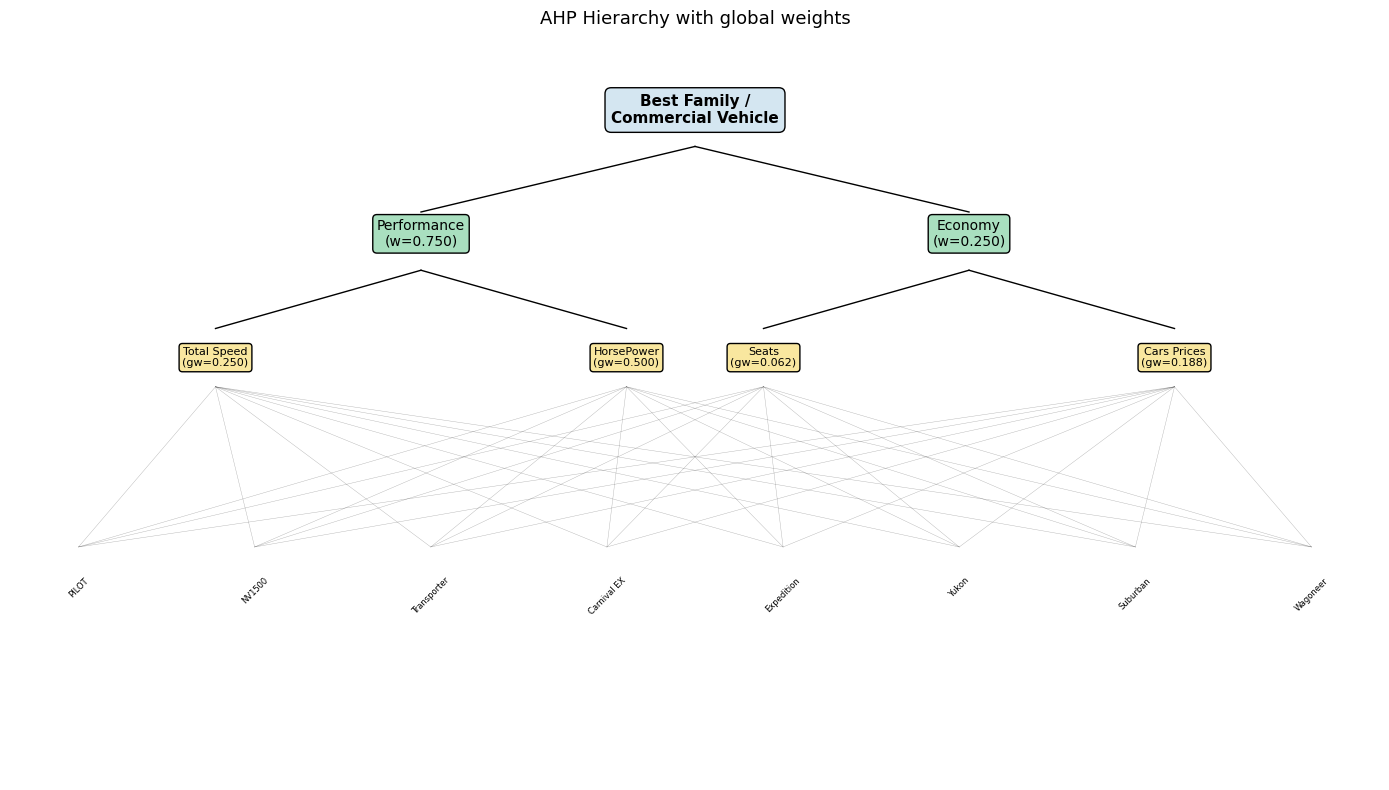

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

# Level 0: Goal
ax.text(5, 9.2, "Best Family /\nCommercial Vehicle", ha="center", va="center",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", fc="#d4e6f1"))

# Level 1: Categories
cat_x = [3, 7]
for cx, cat, wg in zip(cat_x, categories, w_goal):
    ax.plot([5, cx], [8.7, 7.8], "k-", lw=1)
    ax.text(cx, 7.5, f"{cat}\n(w={wg:.3f})", ha="center", va="center",
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="#a9dfbf"))

# Level 2: Criteria
crit_positions = {
    "Total Speed": (1.5, 5.8),
    "HorsePower":  (4.5, 5.8),
    "Seats":       (5.5, 5.8),
    "Cars Prices": (8.5, 5.8),
}
parent_x = {"Total Speed": 3, "HorsePower": 3, "Seats": 7, "Cars Prices": 7}

for crit, (cx, cy) in crit_positions.items():
    ax.plot([parent_x[crit], cx], [7.0, cy + 0.4], "k-", lw=1)
    ax.text(cx, cy, f"{crit}\n(gw={global_weights[crit]:.3f})", ha="center",
            va="center", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="#f9e79f"))

# Level 3: Alternatives
n = len(ahp_alts)
alt_xs = np.linspace(0.5, 9.5, n)
for xi, alt in zip(alt_xs, ahp_alts):
    for crit, (cx, cy) in crit_positions.items():
        ax.plot([cx, xi], [cy - 0.4, 3.2], "k-", lw=0.3, alpha=0.3)
    ax.text(xi, 2.8, alt, ha="center", va="top", fontsize=6, rotation=45)

ax.set_title("AHP Hierarchy with global weights", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

# Comparison: UTA vs AHP

In [ ]:
# Build rank vectors for the 8 shared alternatives
uta_scores_shared = {alt: result["_utilities"][alt] for alt in ahp_alts}
uta_ranking_shared = sorted(uta_scores_shared, key=lambda x: uta_scores_shared[x], reverse=True)

uta_ranks = {alt: rank for rank, alt in enumerate(uta_ranking_shared, 1)}
ahp_ranks = {alt: rank for rank, alt in enumerate(ahp_ranking, 1)}

print(f"{'Car':30s}  {'UTA rank':>9}  {'AHP rank':>9}  {'Δ':>4}")
print("-" * 60)
for alt in ahp_alts:
    delta = abs(uta_ranks[alt] - ahp_ranks[alt])
    print(f"{alt:30s}  {uta_ranks[alt]:9d}  {ahp_ranks[alt]:9d}  {delta:4d}")

Car                              UTA rank   AHP rank     Δ
------------------------------------------------------------
PILOT                                   5          6     1
NV1500                                  7          5     2
Transporter                             6          8     2
Carnival EX                             8          2     6
Expedition                              1          4     3
Yukon                                   2          1     1
Suburban                                3          7     4
Wagoneer                                4          3     1


In [ ]:
uta_rank_vec = [uta_ranks[alt] for alt in ahp_alts]
ahp_rank_vec = [ahp_ranks[alt] for alt in ahp_alts]

tau, p_value = kendalltau(uta_rank_vec, ahp_rank_vec)
print(f"\nKendall's τ = {tau:.4f}  (p-value = {p_value:.4f})")

# Best / worst comparison
uta_best  = uta_ranking_shared[0]
uta_worst = uta_ranking_shared[-1]
ahp_best  = ahp_ranking[0]
ahp_worst = ahp_ranking[-1]
print(f"\nUTA  — best: {uta_best},  worst: {uta_worst}")
print(f"AHP  — best: {ahp_best},  worst: {ahp_worst}")
if uta_best == ahp_best:
    print("Both methods agree on the best alternative.")
else:
    print("Methods DISAGREE on the best alternative.")
if uta_worst == ahp_worst:
    print("Both methods agree on the worst alternative.")
else:
    print("Methods DISAGREE on the worst alternative.")


Kendall's τ = 0.0714  (p-value = 0.9049)

UTA  — best: Expedition,  worst: Carnival EX
AHP  — best: Yukon,  worst: Transporter
Methods DISAGREE on the best alternative.
Methods DISAGREE on the worst alternative.


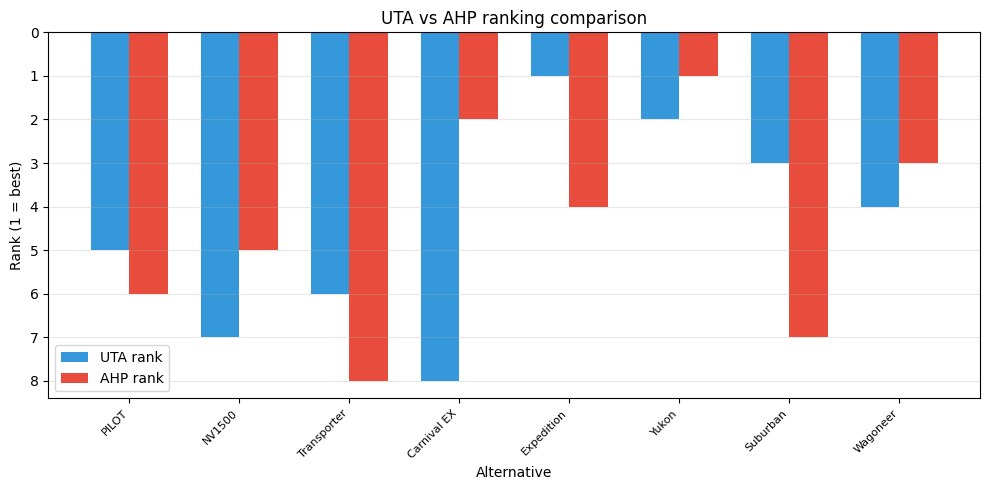

In [ ]:
# Side-by-side rank comparison chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ahp_alts))
width = 0.35

ax.bar(x - width / 2, [uta_ranks[a] for a in ahp_alts], width, label="UTA rank", color="#3498db")
ax.bar(x + width / 2, [ahp_ranks[a] for a in ahp_alts], width, label="AHP rank", color="#e74c3c")

ax.set_xlabel("Alternative")
ax.set_ylabel("Rank (1 = best)")
ax.set_title("UTA vs AHP ranking comparison")
ax.set_xticks(x)
ax.set_xticklabels(ahp_alts, rotation=45, ha="right", fontsize=8)
ax.legend()
ax.invert_yaxis()  # rank 1 at top
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Discussion

The Kendall's τ coefficient measures the ordinal correlation between the two
rankings. A value close to 1 indicates strong agreement, close to 0 indicates
no correlation, and negative values indicate disagreement.

Key differences between the methods:
- **UTA** derives weights and marginal value functions from pairwise preference
  constraints using linear programming — it is data-driven and preference-based.
- **AHP** uses subjective pairwise comparisons on the Saaty 1–9 scale and
  the eigenvector method — it reflects the decision maker's holistic judgment.
- The HorsePower comparison matrix was intentionally made inconsistent
  (CR > 0.1), and the inconsistency analysis revealed where the DM's
  judgments were most contradictory.
- Differences in the final rankings are mainly driven by the different
  weighting mechanisms and the subjective nature of AHP comparisons.